# Проект: Аналитика мобильных игр

Представьте, что вы работаете в компании, которая разрабатывает мобильные игры. К вам пришел менеджер с рядом задач по исследованию нескольких аспектов мобильного приложения:

- Задача 1: В первую очередь, его интересует показатель retention. Напишите функцию для его подсчета.
- Задача 2: Помимо этого, в компании провели A/B тестирование наборов акционных предложений. На основе имеющихся данных определите, какой набор можно считать лучшим и на основе каких метрик стоит принять правильное решение.
- Задача 3: Предложите метрики для оценки результатов последнего прошедшего тематического события в игре.

### Задача 1. Функция Retention

Retention – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока). Данные лежат в папке shared и имеют следующую структуру:

 - shared/problem1-reg_data.csv – данные о времени регистрации
 - shared/problem1-auth_data.csv – данные о времени захода пользователей в игру

Функция должна быть написана на python. В ходе решения можно тестировать работу функции как на полном датасете, так и на части (сэмпле) данных.

Импорт библиотек

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency

**1. Загрузка данных и EDA**

**1.1 Таблица shared/problem1-reg_data.csv – данные о времени регистрации**

In [2]:
registration = pd.read_csv('../shared/problem1-reg_data.csv', sep=';')

Оценка размера, структуры и типов данных

In [3]:
registration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   reg_ts  1000000 non-null  int64
 1   uid     1000000 non-null  int64
dtypes: int64(2)
memory usage: 15.3 MB


In [4]:
registration.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


Поиск пропущенных значений -> пропуски отсутствуют

In [5]:
registration.isna().sum()

reg_ts    0
uid       0
dtype: int64

Проверка на дубликаты - полных дубликатов строк и дубликатов по пользователям -> нет дубликатов

In [6]:
registration.duplicated().sum()

0

In [7]:
registration['uid'].duplicated().sum()

0

Преобразование формата времени и создаем поле дата без времени

In [8]:
registration['reg_ts'] = pd.to_datetime(registration['reg_ts'], unit='s')

In [9]:
registration['reg_ts_date'] = registration['reg_ts'].dt.date
registration['reg_ts_date'] = pd.to_datetime(registration['reg_ts_date'])

In [10]:
registration.head()

,reg_ts,uid,reg_ts_date
0,1998-11-18 09:43:43,1,1998-11-18
1,1999-07-22 22:38:09,2,1999-07-22
2,2000-01-13 22:27:27,3,2000-01-13
3,2000-05-28 14:19:01,4,2000-05-28
4,2000-09-16 11:21:53,5,2000-09-16


**1.2 Таблица shared/problem1-auth_data.csv – данные о времени захода пользователей в игру**

In [11]:
authentication = pd.read_csv('../shared/problem1-auth_data.csv', sep=';')

Оценка размера, структуры и типов данных

In [12]:
authentication.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   auth_ts  int64
 1   uid      int64
dtypes: int64(2)
memory usage: 146.5 MB


In [13]:
authentication.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


Поиск пропущенных значений -> пропуски отсутствуют

In [14]:
authentication.isna().sum()

auth_ts    0
uid        0
dtype: int64

Проверка на наличие полных дубликатов строк -> нет дубликатов

In [15]:
authentication.duplicated().sum()

0

Преобразование формата времени и создаем поле дата без времени

In [16]:
authentication['auth_ts'] = pd.to_datetime(authentication['auth_ts'], unit='s')

In [17]:
authentication['auth_ts_date'] = authentication['auth_ts'].dt.date
authentication['auth_ts_date'] = pd.to_datetime(authentication['auth_ts_date'])

In [18]:
authentication.head()

,auth_ts,uid,auth_ts_date
0,1998-11-18 09:43:43,1,1998-11-18
1,1999-07-22 22:38:09,2,1999-07-22
2,1999-07-25 16:46:46,2,1999-07-25
3,1999-07-31 03:50:15,2,1999-07-31
4,1999-08-05 17:49:39,2,1999-08-05


**1.3 Проверка по обеим таблицам**

Проверка на пересечение пользователей: все ли пользователи, которые заходили в игру, есть в таблице регистраций?

Значение true по всем пользователям говорит, что с данными здесь всё отлично: у каждого вошедшего игрока есть запись о регистрации

In [19]:
authentication.uid.isin(registration.uid).all()

True

Логическая проверка: может ли пользователь авторизоваться раньше, чем зарегистрировался?

Эту проверку проведем на отфильтрованных таблицах, так как объединение полных датасетов требует избыточных ресурсов 

**2. Найдем пользователей, которые зарегистрировались за последние 30 дней, и по всем ним авторизации**

Сравним количество уникальных пользователей в обеих таблицах,
Чтобы увидеть, есть ли те, кто зарегистрировался, но не авторизовался.

Разница равня нулю, значит, всё в порядке - все зарегистрированные пользователи хоть раз авторизовались

In [20]:
registration.uid.nunique() - authentication.uid.nunique()

0

Самая свежая дата регистрации

In [21]:
max_date = registration['reg_ts_date'].max().date()
max_date

datetime.date(2020, 9, 23)

Дата за 30 дней до самой свежей регистрации

In [22]:
start_date = max_date - pd.Timedelta(days=30)
start_date

datetime.date(2020, 8, 24)

Отфильтруем регистрации только за эти 30 дней

In [23]:
reg_30freshdays = registration.query("reg_ts_date >= @start_date")
reg_30freshdays

,reg_ts,uid,reg_ts_date
950869,2020-08-24 00:00:25,1056092,2020-08-24
950870,2020-08-24 00:01:21,1056093,2020-08-24
950871,2020-08-24 00:02:16,1056094,2020-08-24
950872,2020-08-24 00:03:11,1056095,2020-08-24
950873,2020-08-24 00:04:06,1056097,2020-08-24
...,...,...,...
999995,2020-09-23 15:13:54,1110618,2020-09-23
999996,2020-09-23 15:14:46,1110619,2020-09-23
999997,2020-09-23 15:15:39,1110620,2020-09-23
999998,2020-09-23 15:16:31,1110621,2020-09-23


Список пользователей с этими регистрациями

In [24]:
uid_list = reg_30freshdays.uid

Отфильтруем аутентификации только по этим пользователям

In [25]:
auth_30freshdays = authentication.query("uid in @uid_list")
auth_30freshdays

,auth_ts,uid,auth_ts_date
9127657,2020-08-24 00:00:25,1056092,2020-08-24
9127665,2020-08-24 00:01:21,1056093,2020-08-24
9127671,2020-08-24 00:02:16,1056094,2020-08-24
9127678,2020-08-24 00:03:11,1056095,2020-08-24
9127686,2020-08-24 00:04:06,1056097,2020-08-24
...,...,...,...
9601008,2020-09-23 15:13:54,1110618,2020-09-23
9601009,2020-09-23 15:14:46,1110619,2020-09-23
9601010,2020-09-23 15:15:39,1110620,2020-09-23
9601011,2020-09-23 15:16:31,1110621,2020-09-23


**3. Создаем матрицу retention**

Объединяем 2 отфильтрованные таблицы - left join более надежный, так как это защищает логику расчета на случай, если в будущем придут данные, где кол-во уникальных зарегистрированных пользователей больше кол-ва уникальных авторизованных пользователей

In [26]:
df_merge = reg_30freshdays.merge(auth_30freshdays, on='uid', how='left')

In [27]:
df_merge.head()

,reg_ts,uid,reg_ts_date,auth_ts,auth_ts_date
0,2020-08-24 00:00:25,1056092,2020-08-24,2020-08-24 00:00:25,2020-08-24
1,2020-08-24 00:00:25,1056092,2020-08-24,2020-08-29 02:46:22,2020-08-29
2,2020-08-24 00:00:25,1056092,2020-08-24,2020-08-31 05:34:15,2020-08-31
3,2020-08-24 00:00:25,1056092,2020-08-24,2020-09-06 14:40:17,2020-09-06
4,2020-08-24 00:00:25,1056092,2020-08-24,2020-09-12 10:44:59,2020-09-12


In [28]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 82772 entries, 0 to 82771
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   reg_ts        82772 non-null  datetime64[ns]
 1   uid           82772 non-null  int64         
 2   reg_ts_date   82772 non-null  datetime64[ns]
 3   auth_ts       82772 non-null  datetime64[ns]
 4   auth_ts_date  82772 non-null  datetime64[ns]
dtypes: datetime64[ns](4), int64(1)
memory usage: 3.8 MB


Логическая проверка: может ли пользователь авторизоваться раньше, чем зарегистрировался?

Эту проверку проведем на отфильтрованных таблицах, так как объединение полных датасетов требует избыточных ресурсов 

Метод .any() покажет, есть ли в датафрейме хотя бы одна строка, нарушающая логику.

Возвращается False — всё отлично, аномалий нет, ни один пользователь не авторизовался раньше чем зарегистрировался

In [29]:
(df_merge.auth_ts_date < df_merge.reg_ts_date).any()

False

Создаем датасет для расчета retention (только id, дата регистрации и дата аутентификации)

In [30]:
df_retention = df_merge[['uid', 'reg_ts_date', 'auth_ts_date']].copy()
df_retention.rename(columns={'reg_ts_date': 'cohort_day'}, inplace=True)

Рассчитываем номер периода в днях

In [31]:
df_retention['period_number'] = (df_retention.auth_ts_date - df_retention.cohort_day).dt.days

In [32]:
df_retention.head()

,uid,cohort_day,auth_ts_date,period_number
0,1056092,2020-08-24,2020-08-24,0
1,1056092,2020-08-24,2020-08-29,5
2,1056092,2020-08-24,2020-08-31,7
3,1056092,2020-08-24,2020-09-06,13
4,1056092,2020-08-24,2020-09-12,19


Агрегируем данные по когортам и рассчитанному номеру периода для уникальных пользователей

In [33]:
df_cohort = df_retention.groupby(['cohort_day', 'period_number'])\
                        .agg(n_customers=('uid', 'nunique')).reset_index()

In [34]:
df_cohort.head()

,cohort_day,period_number,n_customers
0,2020-08-24,0,1565
1,2020-08-24,1,28
2,2020-08-24,2,65
3,2020-08-24,3,67
4,2020-08-24,4,80


Создаем сводную таблицу для когортного анализа

In [35]:
cohort_pivot = df_cohort.pivot_table(index='cohort_day', columns='period_number', values='n_customers')
cohort_pivot

period_number,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
cohort_day,,,,,,,,,,,,,,,,,,,,,
2020-08-24,1565.0,28.0,65.0,67.0,80.0,90.0,119.0,94.0,77.0,81.0,...,55.0,57.0,54.0,70.0,49.0,51.0,49.0,49.0,44.0,20.0
2020-08-25,1567.0,31.0,69.0,75.0,89.0,83.0,83.0,98.0,58.0,90.0,...,55.0,56.0,51.0,51.0,69.0,44.0,49.0,50.0,36.0,NaN
2020-08-26,1570.0,23.0,54.0,66.0,71.0,101.0,103.0,94.0,72.0,68.0,...,41.0,67.0,51.0,43.0,46.0,44.0,43.0,26.0,NaN,NaN
2020-08-27,1573.0,26.0,53.0,75.0,82.0,87.0,97.0,90.0,68.0,85.0,...,73.0,47.0,47.0,61.0,53.0,43.0,23.0,NaN,NaN,NaN
2020-08-28,1575.0,32.0,72.0,83.0,75.0,99.0,98.0,86.0,88.0,83.0,...,69.0,74.0,64.0,45.0,58.0,40.0,NaN,NaN,NaN,NaN
2020-08-29,1578.0,40.0,59.0,73.0,90.0,87.0,110.0,90.0,72.0,95.0,...,70.0,67.0,55.0,56.0,27.0,NaN,NaN,NaN,NaN,NaN
2020-08-30,1580.0,29.0,55.0,62.0,85.0,94.0,104.0,88.0,68.0,68.0,...,57.0,64.0,59.0,28.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-31,1583.0,29.0,58.0,67.0,81.0,109.0,103.0,106.0,76.0,85.0,...,63.0,44.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,1586.0,32.0,65.0,67.0,73.0,102.0,89.0,102.0,65.0,86.0,...,69.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Рассчитываем размеры когорт (первый столбец сводной таблицы)

In [36]:
cohort_size = cohort_pivot.iloc[:, 0]

Вычисляем коэффициенты удержания, деля на размер когорты -> матрица готова

In [37]:
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
retention_matrix

period_number,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
cohort_day,,,,,,,,,,,,,,,,,,,,,
2020-08-24,1.0,0.017891,0.041534,0.042812,0.051118,0.057508,0.076038,0.060064,0.049201,0.051757,...,0.035144,0.036422,0.034505,0.044728,0.031310,0.032588,0.031310,0.031310,0.028115,0.01278
2020-08-25,1.0,0.019783,0.044033,0.047862,0.056796,0.052967,0.052967,0.062540,0.037013,0.057435,...,0.035099,0.035737,0.032546,0.032546,0.044033,0.028079,0.031270,0.031908,0.022974,NaN
2020-08-26,1.0,0.014650,0.034395,0.042038,0.045223,0.064331,0.065605,0.059873,0.045860,0.043312,...,0.026115,0.042675,0.032484,0.027389,0.029299,0.028025,0.027389,0.016561,NaN,NaN
2020-08-27,1.0,0.016529,0.033694,0.047680,0.052130,0.055308,0.061666,0.057216,0.043229,0.054037,...,0.046408,0.029879,0.029879,0.038779,0.033694,0.027336,0.014622,NaN,NaN,NaN
2020-08-28,1.0,0.020317,0.045714,0.052698,0.047619,0.062857,0.062222,0.054603,0.055873,0.052698,...,0.043810,0.046984,0.040635,0.028571,0.036825,0.025397,NaN,NaN,NaN,NaN
2020-08-29,1.0,0.025349,0.037389,0.046261,0.057034,0.055133,0.069708,0.057034,0.045627,0.060203,...,0.044360,0.042459,0.034854,0.035488,0.017110,NaN,NaN,NaN,NaN,NaN
2020-08-30,1.0,0.018354,0.034810,0.039241,0.053797,0.059494,0.065823,0.055696,0.043038,0.043038,...,0.036076,0.040506,0.037342,0.017722,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-31,1.0,0.018320,0.036639,0.042325,0.051169,0.068857,0.065066,0.066961,0.048010,0.053696,...,0.039798,0.027795,0.018951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,1.0,0.020177,0.040984,0.042245,0.046028,0.064313,0.056116,0.064313,0.040984,0.054224,...,0.043506,0.015763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**4. Строим график медианного retention**

Добавляем последней строкой медиану retention по каждому месяцу, используем датасет без нулевого месяца 

In [38]:
retention_matrix_median = retention_matrix.iloc[:, 1:].copy()
retention_matrix_median.loc['Median'] = retention_matrix_median.median(axis=0)

Забираем только значения медианного retention

In [39]:
median_retention = retention_matrix_median.loc['Median']*100
median_retention.head()

period_number
1    1.949222
2    4.032258
3    4.587421
4    5.212969
5    6.275535
Name: Median, dtype: float64

График медианного retention

Text(0.5, 1.0, 'Кривая медианного Retention')

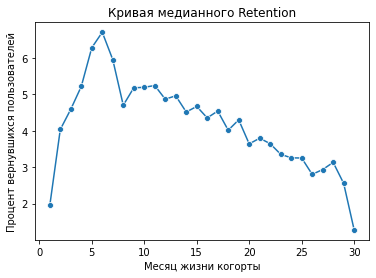

In [40]:
sns.lineplot(x=median_retention.index, y=median_retention.values, marker='o')
plt.xlabel("Месяц жизни когорты")
plt.ylabel("Процент вернувшихся пользователей")
plt.title("Кривая медианного Retention")

**5. Создаем функцию retention**

In [41]:
def retention_function(reg_path, auth_path, start_date=None, end_date=None, max_days=30):
    """
    Функция для расчета retention игроков по дням от даты регистрации.
    
    :param reg_path: путь к файлу с данными о регистрациях - необходимые колонки "время регистрации" и "id пользователя"
    :param auth_path: путь к файлу с данными об авторизациях - необходимые колонки "время авторизации" и "id пользователя"
    :param start_date: начальная дата для фильтрации когорт (опционально)
    :param end_date: конечная дата для фильтрации когорт (опционально)
    :param max_days: количество дней удержания для отображения (по умолчанию 30)
    :return: DataFrame с матрицей retention
    """
    
    # 1. Считываем данные и преобразуем даты
    # DataFrame с регистрациями
    registration = pd.read_csv(reg_path, sep=';')
    registration['reg_ts'] = pd.to_datetime(registration['reg_ts'], unit='s')
    registration['reg_ts_date'] = registration['reg_ts'].dt.normalize()
    
    # DataFrame с авторизациями
    authentication = pd.read_csv(auth_path, sep=';')
    authentication['auth_ts'] = pd.to_datetime(authentication['auth_ts'], unit='s')
    authentication['auth_ts_date'] = authentication['auth_ts'].dt.normalize()

    
    # 2. Фильтруем данные (если даты заданы)
    if start_date is not None:
        registration = registration.query("reg_ts_date >= @start_date")
        
    if end_date is not None:
        registration = registration.query("reg_ts_date <= @end_date")
    
    uid_list = registration.uid
    authentication = authentication.query("uid in @uid_list")
        
    
    # 3. Объединяем данные и считаем разницу в днях
    df_merge = registration.merge(authentication, on='uid', how='left')
    
    # создаем датасет для расчета retention (только id, дата регистрации и дата аутентификации)
    df_retention = df_merge[['uid', 'reg_ts_date', 'auth_ts_date']].copy()
    df_retention.rename(columns={'reg_ts_date': 'cohort_day'}, inplace=True)
    
    # Рассчитываем номер периода в днях
    df_retention['period_number'] = (df_retention.auth_ts_date - df_retention.cohort_day).dt.days
    
    # Оставляем только те периоды, которые укладываются в max_days
    df_retention = df_retention.query("0 <= period_number <= @max_days")
    
    # Агрегируем данные по когортам и рассчитанному номеру периода для уникальных пользователей
    df_cohort = df_retention.groupby(['cohort_day', 'period_number'])\
                        .agg(n_customers=('uid', 'nunique')).reset_index()
    
    
    # 4. Строим и нормируем матрицу retention
    cohort_pivot = df_cohort.pivot_table(index='cohort_day', columns='period_number', values='n_customers')

    cohort_size = cohort_pivot.iloc[:, 0]
    
    retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
    
    
    return retention_matrix

### Задача 2.  Анализ результатов A/B-тестирования

Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

**1. Загрузка данных**

In [42]:
data = pd.read_csv('Проект_1_Задание_2.csv', sep=';')

In [43]:
data.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404770 entries, 0 to 404769
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    404770 non-null  int64 
 1   revenue    404770 non-null  int64 
 2   testgroup  404770 non-null  object
dtypes: int64(2), object(1)
memory usage: 9.3+ MB


**2. Определяем тестовую и контрольную группы**

Новое поле - пользователь платящий или нет

In [45]:
data['is_paying'] = (data['revenue'] > 0).astype(int)
data.tail()

,user_id,revenue,testgroup,is_paying
404765,404766,0,a,0
404766,404767,0,b,0
404767,404768,231,a,1
404768,404769,0,a,0
404769,404770,0,b,0


Группируем по типу группы и считаем кол-во уникальных пользоватлей и кол-во платящих пользователей

In [46]:
data_group = data.groupby('testgroup').agg(n_users=('user_id', 'nunique'), n_paying_users=('is_paying', 'sum')).reset_index()
data_group

,testgroup,n_users,n_paying_users
0,a,202103,1928
1,b,202667,1805


По условию задачи:
 - В контрольной группе: 1928 платящих из 202103 пользователей -> получается, группа a - контрольная
 - В тестовой группе: 1805 платящих из 202667 пользователей -> получается, группа b - тестовая 

**3. Исследовательский анализ данных**

2 датафрейма по типам группы

In [47]:
data_a = data.query("testgroup == 'a'")
data_b = data.query("testgroup == 'b'")

**3.1 Исследуем распределение выручки по платящим пользователям в контрольной группе А**

In [48]:
data_a_paying = data_a.query('revenue > 0')

In [49]:
data_a_paying.revenue.describe()

count     1928.000000
mean      2663.998444
std       9049.039763
min        200.000000
25%        257.000000
50%        311.000000
75%        361.000000
max      37433.000000
Name: revenue, dtype: float64

График распределения выручки группы А

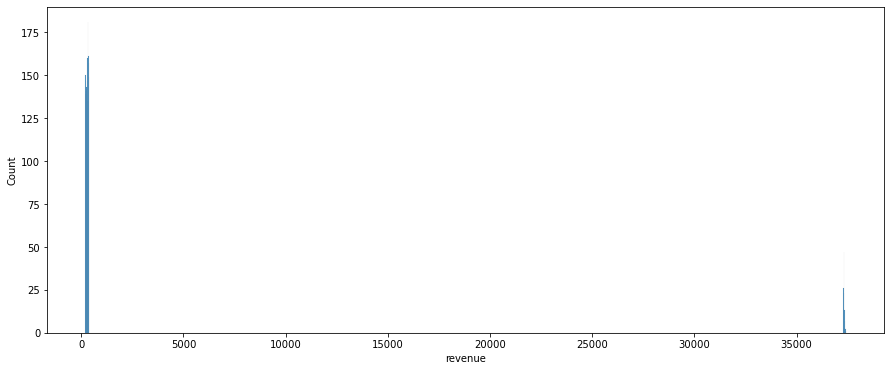

In [50]:
plt.figure(figsize=(15, 6))
sns.histplot(data_a_paying.revenue)

**3.2 Исследуем распределение выручки по платящим пользователям в тестовой группе В**

In [51]:
data_b_paying = data_b.query('revenue > 0')

In [52]:
data_b_paying.revenue.describe()

count    1805.000000
mean     3003.658172
std       572.619709
min      2000.000000
25%      2513.000000
50%      3022.000000
75%      3478.000000
max      4000.000000
Name: revenue, dtype: float64

График распределения выручки группы В

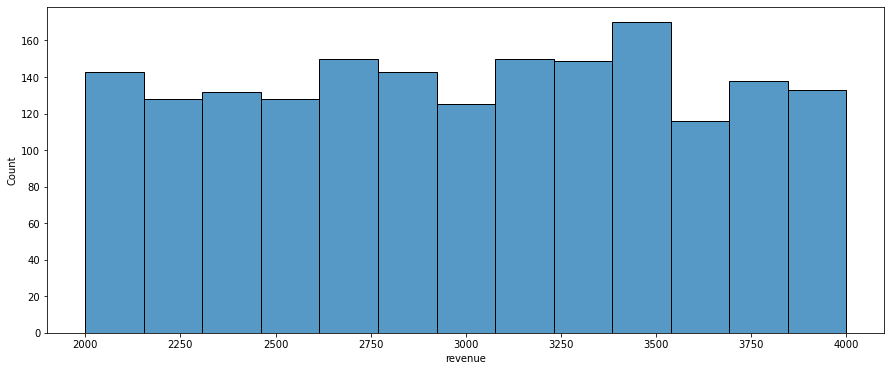

In [53]:
plt.figure(figsize=(15, 6))
sns.histplot(data_b_paying.revenue)

Выводы из исследования распределений - портрет платящей аудитории:

 - Портрет группы а (контрольной). 
Это классическое разделение на «обычных игроков» (которые платят совсем немного, около 200–400)
и супер-плательщиков, которых в игровой индустрии называют «китами» (они тратят огромные суммы — около 37 000).

 - Портрет группы b (тестовой).
«Киты» полностью исчезли, но при этом пропали и совсем мелкие платежи по 200.
Все платящие пользователи тратят примерно одинаковую, среднюю сумму (от 2000 до 4000).

**3.3 Поисследуем «китов» в группе А**

Количество "китов"

In [54]:
a_bigusers = data_a_paying.query('revenue >= 35000').user_id.count()
a_bigusers

123

Доля "китов"

In [55]:
a_bigusers_rate = round(a_bigusers/data_a_paying.user_id.count(), 2)
a_bigusers_rate

0.06

Сколько денег приносят «киты» 

In [56]:
a_bigrevenue = data_a_paying.query('revenue >= 35000').revenue.sum()
a_bigrevenue

4590252

Доля выручки "китов"

In [57]:
a_bigrevenue_rate = round(data_a_paying.query('revenue >= 35000').revenue.sum()/data_a_paying.revenue.sum(), 2)
a_bigrevenue_rate

0.89

На сколько процентов отличается выручка в группе b по сравнению с группой a:

Суммарная выручка группы а

In [58]:
a_revenue = data_a_paying.revenue.sum()
a_revenue

5136189

Суммарная выручка группы b

In [59]:
b_revenue = data_b_paying.revenue.sum()
b_revenue

5421603

In [60]:
revenue_diff_pct = round(((b_revenue - a_revenue)/a_revenue)*100, 1)
print(f"Выручка в группе b на {revenue_diff_pct}% больше по сравнению с группой a.")

Выручка в группе b на 5.6% больше по сравнению с группой a.


**4. Выбор метрик для анализа**

Оцениваем три ключевые метрики в связке:
- CR (Conversion Rate) в покупку — доля платящих пользователей.
Она показывает, стали ли пользователи охотнее соглашаться на покупку.

- ARPU (Average Revenue Per User) — средняя выручка со всей группы пользователей.

- ARPPU (Average Revenue Per Paying User) — средний чек только платящих игроков.
Он показывает, изменилась ли ценность платящей аудитории.

In [61]:
cr_a = round(data_a.is_paying.sum() / data_a.user_id.count(), 4)
print(f"CR контрольной группы (a) в долях = {cr_a}")

CR контрольной группы (a) в долях = 0.0095


In [62]:
cr_b = round(data_b.is_paying.sum() / data_b.user_id.count(), 4)
print(f"CR тестовой группы (b) в долях = {cr_b}")

CR тестовой группы (b) в долях = 0.0089


In [63]:
arpu_a = round(data_a.revenue.sum() / data_a.user_id.count(), 2)
print(f"ARPU контрольной группы (a) = {arpu_a}")

ARPU контрольной группы (a) = 25.41


In [64]:
arpu_b = round(data_b.revenue.sum() / data_b.user_id.count(), 2)
print(f"ARPU тестовой группы (b) = {arpu_b}")

ARPU тестовой группы (b) = 26.75


In [65]:
arppu_a = round(data_a.revenue.sum() / data_a.is_paying.sum(), 2)
print(f"ARPPU контрольной группы (a) = {arppu_a}")

ARPPU контрольной группы (a) = 2664.0


In [66]:
arppu_b = round(data_b.revenue.sum() / data_b.is_paying.sum(), 2)
print(f"ARPPU тестовой группы (b) = {arppu_b}")

ARPPU тестовой группы (b) = 3003.66


**5. Подбор статистических методов**

**Для CR (Conversion Rate) будем использовать - критерий Хи-квадрат Пирсона:**

Когда мы анализируем конверсию, мы имеем дело с категориальной переменной:
каждый пользователь либо совершил покупку («Да» / 1), либо нет («Нет» / 0). У нас есть две независимые группы: А и B.

Эту информацию мы можем представить в виде таблицы сопряженности,
где на пересечении строк и столбцов будут находиться реальные количества людей:
 - Группа А - Платящие (1) | Неплатящие (0) | Всего 
 - Группа В - Платящие (1) | Неплатящие (0) | Всего

**Для ARPU (Average Revenue Per User) будем использовать - t-тест Уэлча (сравнение средних по всем пользователям):**

Поскольку объем выборки для обеих групп огромен (больше 200 000),
распределение выборочного среднего будет стремиться к нормальному благодаря Центральной предельной теореме (ЦПТ),
даже если исходное распределение выручки имеет экстремальную асимметрию.

А раз распределение средних нормально, то t-тест Уэлча, который не требует равенства дисперсий,
математически применим для сравнения средних.

**Для ARPPU (Average Revenue Per Paying User) будем использовать - t-тест Уэлча (сравнение средних по платящим пользователям):**

Используем t-тест Уэлча, который не требует равенства дисперсий, для ARPPU по той же причине, что и для ARPU.
Здесь выборка меньше (~1800–1900 пользователей), но все еще достаточно велика для ЦПТ.

**6. Проведение статистических тестов**

**6.1 Критерий Хи-квадрат для CR**

Нулевая гипотеза (H0): разницы в конверсии между группами А и B нет.
Изменение набора акционных предложений никак не повлияло на желание пользователей покупать.

Альтернативная гипотеза (H1): разница в конверсии между группами А и B есть, она статистически значима.

Таблица сопряженности из условий задачи и запуск теста:

In [67]:
contingency_table = [
    [1928, 202103 - 1928],  # Группа А
    [1805, 202667 - 1805]   # Группа B
]

In [68]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"p-value: {p_value:.3f}")

p-value: 0.036


Статистический вывод: p_value (0.036) меньше стандартного уровня значимости 0.05,
значит, мы отклоняем нулевую гипотезу, следовательно, разница в конверсиях действительно есть, это не случайный шум.

**6.2 t-тест Уэлча для ARPU**

Нулевая гипотеза (H0): разницы в ARPU между группами А и B нет.
Изменение набора акционных предложений никак не повлияло на среднюю выручку со всей группы пользователей.

Альтернативная гипотеза (H1): разница в ARPU между группами А и B есть, она статистически значима.

Выручка в каждой группе по платящим и неплатящим:

In [69]:
revenue_a = data_a.revenue
revenue_b = data_b.revenue

Используем t-тест Уэлча с параметром equal_var=False, который не требует равенства дисперсий

In [70]:
t_stat_ARPU, p_val_ARPU = stats.ttest_ind(revenue_a, revenue_b, equal_var=False)

print(f"t-статистика ARPU: {t_stat_ARPU}")
print(f"p-значение ARPU (p-value): {p_val_ARPU}")

t-статистика ARPU: -0.6234876562792212
p-значение ARPU (p-value): 0.5329647014130866


Статистический вывод: p_value (0.53) больше стандартного уровня значимости 0.05,
значит, нет оснований отклонить нулевую гипотезу H0 и
мы не можем утверждать, что ARPU в группах статистически различается.

**6.3 t-тест Уэлча для ARPPU**

Нулевая гипотеза (H0): разницы в ARPPU между группами А и B нет.
Изменение набора акционных предложений никак не повлияло на средний чек платящих игроков.

Альтернативная гипотеза (H1): разница в ARPPU между группами А и B есть, она статистически значима.

Выручка только платящих в каждой группе:

In [71]:
paying_revenue_a = data_a_paying.revenue
paying_revenue_b = data_b_paying.revenue

Используем t-тест Уэлча с параметром equal_var=False, который не требует равенства дисперсий

In [72]:
t_stat_ARPPU, p_val_ARPPU = stats.ttest_ind(paying_revenue_a, paying_revenue_b, equal_var=False)

print(f"t-статистика ARPPU: {t_stat_ARPPU}")
print(f"p-значение ARPPU (p-value): {p_val_ARPPU}")

t-статистика ARPPU: -1.644630266430084
p-значение ARPPU (p-value): 0.10020780398916015


Статистический вывод: p_value (0.10) больше стандартного уровня значимости 0.05,
значит, нет оснований отклонить нулевую гипотезу H0 и
мы не можем утверждать, что ARPPU в группах статистически различается.

**7. Выводы и рекомендации**

**7.1 Аналитический вывод**

 - Средняя выручка по всем пользователям (ARPU).

Эта метрика статистически значимо не изменилась (p-value=0.53 > 0.05).
Это означает, что новый набор акционных предложений (группа B) не приносит компании больше денег в расчете на всю аудиторию,
чем текущий (группа A). 

 - Поведение пользователей (CR).

Мы наблюдаем статистически значимое снижение конверсии в покупку в тестовой группе B (p-value=0.036 < 0.05).
Конверсия упала с 0.95% в контрольной группе (А) до 0.89% в тестовой группе (В).
Это важный негативный сигнал для бизнеса: новые предложения отталкивают часть пользователей,
из-за чего они отказываются от покупок.

 - Средний чек платящих пользователей (ARPPU).

Разница в среднем чеке среди тех, кто совершил покупку, не является статистически значимой (p-value=0.10 > 0.05).
Таким образом, мы не можем говорить, что платящие пользователи в группе B стали тратить значимо больше, чем в группе A.

**7.2 Структура выручки**

- В контрольной группе A выручка сильно поляризована: основную выручку делают единичные крупные плательщики (6% «китов» приносят 89% выручки) и мы видим высокую конверсию в покупку (0.95%).

- В тестовой группе B платящие пользователи распределены более равномерно в среднем сегменте, однако это привело к падению общей конверсии (0.89%).

**7.3 Итоговая рекомендация для бизнеса**

На основе проведенного анализа раскатывать тестовый набор предложений (группу B) на всех пользователей не рекомендуется. 

Внедрение изменений приведет к статистическому снижению конверсии в покупку (мы потеряем часть платящей аудитории),
но при этом мы не получим статистически подтвержденного прироста ни в среднем чеке платящего пользователя,
ни в общей выручке компании. 

### Задача 3. Продуктовые метрики для внутриигрового события (ивента)

В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

**1. Метрики для оценки стандартного тематического события**

**Блок 1: Метрики вовлечения и участия (Engagement)**

Они показывают, насколько ивент вообще заинтересовал игроков и сколько времени они в нем проводят:

- Event DAU / MAU: сколько уникальных пользователей заходили в игру/ивент в дни его проведения.

- Доля участников (Participation Rate): процент игроков от общего DAU, которые сыграли хотя бы один уровень ивента. Это показывает, насколько привлекательной была тема ивента (визуально, по наградам).

- Среднее время сессии и среднее количество сыгранных уровней в день на одного игрока во время ивента (сравниваем с обычными днями без ивентов).

**Блок 2: Метрики прохождения и баланса (Progression)**

Они показывают, не был ли ивент слишком сложным или слишком простым:

- Воронка прохождения уровней (Event Funnel): какой процент игроков дошел до 2-го, 3-го, 5-го уровня и до финала. Это покажет «узкие горлышка» — уровни, на которых ломается сложность.

- Доля завершивших ивент (Completion Rate): процент игроков (из тех, кто начал), которые полностью прошли все уровни и получили финальную награду. Если процент слишком низкий — ивент был слишком сложным; если слишком высокий — игроки пролетели его мгновенно и заскучали.

- Win/Loss Ratio: соотношение побед и поражений на уровнях ивента.

**Блок 3: Метрики монетизации (Monetization)**

Ивенты — отличный повод для покупок:

- Revenue во время ивента: выросла ли общая выручка в эти дни по сравнению с аналогичным периодом без ивента.
 
- Конверсия в покупку внутри ивента (Event CR): доля игроков, совершивших покупку.
 
- Средний чек покупателя (ARPPU) в дни ивента.

**Блок 4: Метрики удержания (Retention)**

- Short-term Retention (например, 1-day, 3-day, 7-day retention): стали ли пользователи лучше возвращаться в игру в те дни, когда шел ивент.
 
- Доля вернувшихся «спящих» игроков (Re-engagement Rate): сколько неактивных игроков вернулись в игру специально ради этого события.

**2. Новый набор метрик, если усложнить механику — добавить откат на несколько уровней назад при каждом проигрыше**

**Блок 1: Метрики вовлечения и участия (Engagement)**

По сути метрики "Event DAU / MAU" и "Доля участников" не поменяются.

Нас интересует изменение метрики - Среднее время сессии и среднее количество сыгранных уровней в день на одного игрока
во время ивента (сравниваем с обычными днями без ивентов и сравниваем с стандартным тематическим событием). 

Такое сравнение позволит изолировать эффект этой механики отката. Например:
Если время сессии и количество попыток выросли по сравнению со стандартным ивентом, значит, механика заставила игроков дольше играть.
Если же эти показатели упали, это тревожный сигнал: игроки быстро сдаются после первых же откатов и закрывают игру.

**Блок 2: Метрики прохождения и баланса (Progression) - самый важный!**

- Количество откатов, которое совершает средний игрок: покажет общую «болезненность» ивента

- Доля игроков, которые застряли в бесконечном цикле «прошел-откатился-прошел-откатился»

- Cреднее количество попыток на один уровень

- Воронка прохождения уровней (Event Funnel): какой процент игроков дошел до 2-го, 3-го, 5-го уровня и до финала. Это покажет «узкие горлышка» — уровни, на которых ломается сложность.

**Блок 3: Метрики монетизации (Monetization)**

- Revenue во время ивента: выросла ли общая выручка в эти дни по сравнению с:
  - а - аналогичным периодом без ивента
  - б - аналогичным периодом с обычным ивентом
 
- Доля покупок, совершенных именно на экране поражения: покупка дополнительных ходов, чтобы предотвратить откат
    
- Доля платящих на разных этапах ивента (по уровням): возможно, на последних уровнях, где цена отката максимальна, монетизация резко возрастает.

**Блок 4: Метрики удержания и оттока (Retention & Churn)**

- Churn Rate (отток) непосредственно после отката: cколько игроков закрыли приложение или вообще удалили его в течение часа после того, как откатились назад? Если процент таких уходов высок, значит, сложность ломает удовольствие от игры.

- Short-term Retention (например, 1-day, 3-day, 7-day retention): Как изменился общий Retention участников этого сурового ивента по сравнению с обычным?